IMPORTING

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sent=pd.read_csv("C:/Users/alikc/OneDrive/Desktop/jail/Jail-project/data/Sentencing.csv")


C:\Users\alikc\AppData\Local\Temp\ipykernel_19076\1349642326.py:5: DtypeWarning: Columns (10,11,14,25) have mixed types. Specify dtype option on import or set low_memory=False.
  sent=pd.read_csv("C:/Users/alikc/OneDrive/Desktop/jail/Jail-project/data/Sentencing.csv")


Basic inspection

In [40]:
print(sent.head())
sent.info()

        CASE_ID  CASE_PARTICIPANT_ID   RECEIVED_DATE   OFFENSE_CATEGORY  \
0  1.300000e+11         1.030000e+12  8/15/1984 0:00  PROMIS Conversion   
1  1.300000e+11         1.030000e+12  8/15/1984 0:00  PROMIS Conversion   
2  1.300000e+11         1.030000e+12  8/15/1984 0:00  PROMIS Conversion   
3  1.300000e+11         1.030000e+12  8/15/1984 0:00  PROMIS Conversion   
4  1.300000e+11         1.030000e+12  8/15/1984 0:00  PROMIS Conversion   

   PRIMARY_CHARGE_FLAG     CHARGE_ID  CHARGE_VERSION_ID  \
0                False  3.590000e+12       5.956254e+10   
1                False  3.590000e+12       5.032421e+10   
2                False  3.590000e+12       6.758690e+10   
3                False  3.590000e+12       6.758355e+10   
4                False  3.590000e+12       5.021900e+10   

  DISPOSITION_CHARGED_OFFENSE_TITLE  CHARGE_COUNT DISPOSITION_DATE  ...  \
0               FIRST DEGREE MURDER             2  12/17/2014 0:00  ...   
1                     HOME INVASION         

Check for missing values (percent)

In [41]:
missing_percent = (sent.isnull().sum() / len(sent)) * 100
print(missing_percent)

CASE_ID                               0.000000
CASE_PARTICIPANT_ID                   0.000000
RECEIVED_DATE                         0.000000
OFFENSE_CATEGORY                      0.000000
PRIMARY_CHARGE_FLAG                   0.000000
CHARGE_ID                             0.000000
CHARGE_VERSION_ID                     0.000000
DISPOSITION_CHARGED_OFFENSE_TITLE     0.000000
CHARGE_COUNT                          0.000000
DISPOSITION_DATE                      0.000000
DISPOSITION_CHARGED_CHAPTER           0.000000
DISPOSITION_CHARGED_ACT               1.780087
DISPOSITION_CHARGED_SECTION           1.780087
DISPOSITION_CHARGED_CLASS             0.006212
DISPOSITION_CHARGED_AOIC              0.007846
CHARGE_DISPOSITION                    0.000000
CHARGE_DISPOSITION_REASON            99.552445
SENTENCE_JUDGE                        0.242576
SENTENCE_COURT_NAME                   0.457036
SENTENCE_COURT_FACILITY               0.754207
SENTENCE_PHASE                        0.000000
SENTENCE_DATE

Filter dataset

In [42]:
sent_filtered = sent[(sent['COMMITMENT_TYPE'].notna()) & (sent['COMMITMENT_TERM'].notna())].copy()
print(f"Original dataset shape: {sent.shape}")
print(f"Filtered dataset (both commitment fields present) shape: {sent_filtered.shape}")

Original dataset shape: (305884, 41)
Filtered dataset (both commitment fields present) shape: (304016, 41)


Normalize commitment unit text early so comparisons are reliable

In [43]:
sent_filtered['COMMITMENT_UNIT'] = (
    sent_filtered['COMMITMENT_UNIT'].fillna('').astype(str).str.strip().str.upper()
)

print('COMMITMENT_TYPE counts:')
print(sent_filtered['COMMITMENT_TYPE'].value_counts())
print('\nCOMMITMENT_UNIT unique examples:')
print(sent_filtered['COMMITMENT_UNIT'].unique()[:50])

COMMITMENT_TYPE counts:
COMMITMENT_TYPE
Illinois Department of Corrections               161813
Probation                                        101374
Cook County Department of Corrections             11332
710/410 Probation                                  6438
Conditional Discharge                              3899
Intensive Probation Services                       3766
Court Supervision                                  3594
Mental Health Probation                            2838
Cook County Boot Camp                              2356
Intensive Drug Probation Services                  1892
Drug Court Probation                               1485
Sex Offender Probation                              885
Gang Probation                                      667
2nd Chance Probation                                545
Cook County Impact Incarceration Program            283
Veteran's Court Probation                           261
Inpatient Mental Health Services                    230
Repeat O

Drop rows where COMMITMENT_UNIT is in the ignore list

In [44]:
units_to_ignore = ['POUNDS', 'OUNCES', 'KILOS', 'GRAMS', 'DOLLARS', 'TERM']
print('\nRows with ignored units:', sent_filtered['COMMITMENT_UNIT'].isin(units_to_ignore).sum())
sent_filtered = sent_filtered[~sent_filtered['COMMITMENT_UNIT'].isin(units_to_ignore)].copy()
print(f"After dropping ignored units: {sent_filtered.shape}")


Rows with ignored units: 2479
After dropping ignored units: (301537, 41)


Convert COMMITMENT_TERM to numeric (coerce errors to NaN) before computing years

In [45]:
sent_filtered['COMMITMENT_TERM_NUM'] = pd.to_numeric(sent_filtered['COMMITMENT_TERM'], errors='coerce')

Map units to year factors (make sure keys are uppercase, normalized)

In [46]:
unit_to_years = {
    'DAY': 1/365,
    'DAYS': 1/365,
    'WEEK': 7/365,
    'WEEKS': 7/365,
    'MONTH': 1/12,
    'MONTHS': 1/12,
    'YEAR': 1,
    'YEARS': 1,
    'YEAR(S)': 1,
    'HOUR': 1/(24*365),
    'HOURS': 1/(24*365),
    # special cases
}

sent_filtered['unit_factor'] = sent_filtered['COMMITMENT_UNIT'].map(unit_to_years)

# Compute sentence years normally (term * unit factor)
sent_filtered['sentence_years'] = sent_filtered['COMMITMENT_TERM_NUM'] * sent_filtered['unit_factor']

# Override special units so they are not multiplied by COMMITMENT_TERM
# NATURAL LIFE should be a fixed 100 years regardless of COMMITMENT_TERM
sent_filtered.loc[sent_filtered['COMMITMENT_UNIT'] == 'NATURAL LIFE', 'sentence_years'] = 100
# TIME SERVED should map to 0 (or could be treated differently if needed)
sent_filtered.loc[sent_filtered['COMMITMENT_UNIT'] == 'TIME SERVED', 'sentence_years'] = 0
sent_filtered = sent_filtered[~sent_filtered['sentence_years'].isna()].copy()
print(sent_filtered['sentence_years'].isna().sum())

#print('\nSample of computed sentence_years:')
print(sent_filtered[['COMMITMENT_TERM', 'COMMITMENT_UNIT', 'COMMITMENT_TERM_NUM', 'unit_factor', 'sentence_years']].head(20))

0
   COMMITMENT_TERM COMMITMENT_UNIT  COMMITMENT_TERM_NUM  unit_factor  \
1             30.0         YEAR(S)                 30.0          1.0   
4             30.0         YEAR(S)                 30.0          1.0   
5             30.0         YEAR(S)                 30.0          1.0   
6             30.0         YEAR(S)                 30.0          1.0   
7             30.0         YEAR(S)                 30.0          1.0   
8             30.0         YEAR(S)                 30.0          1.0   
9             62.0         YEAR(S)                 62.0          1.0   
11            15.0         YEAR(S)                 15.0          1.0   
12            15.0         YEAR(S)                 15.0          1.0   
13            30.0         YEAR(S)                 30.0          1.0   
14            30.0         YEAR(S)                 30.0          1.0   
15             1.0    NATURAL LIFE                  1.0          NaN   
16             1.0    NATURAL LIFE                  1.0       

merging the commitement type

In [47]:
print(sent_filtered[(sent_filtered['COMMITMENT_TYPE']=="Death") | (sent_filtered['COMMITMENT_TYPE']=="nnatural Life") ].head()['COMMITMENT_UNIT'])
#even if it s death in the type it said natural life in the unit so we can work only in the unit for maximum restriction
classes = {
    'Maximum_Restriction': ['Natural Life', 'Death'],  # Level 10
    'State_Prison': ['Illinois Department of Corrections', 'Juvenile IDOC'],  # Level 9
    'County_Jail_Intensive': [
        'Cook County Department of Corrections',
        'Cook County Boot Camp',
        'Cook County Impact Incarceration Program',
        'Vocational Rehabilitation Impact Center(VRIC)'
    ],  # Level 7
    'Part_Time_Jail': ['Periodic Imprisonment'],  # Level 6
    'Institutional_Treatment': ['Inpatient Mental Health Services'],  # Level 5
    'Intensive_Community_Supervision': [
        'Intensive Probation Services',
        'Intensive Drug Probation Services',
        'Sex Offender Probation',
        'Gang Probation',
        'Repeat Offender Probation',
        'Drug Court Probation',
        'Mental Health Probation',
        'Domestic Violence Probation',
        "Veteran's Court Probation"
    ],  # Level 4
    'Standard_Probation': ['Probation', '2nd Chance Probation', 'Home Confinement'],  # Level 3
    'Deferred_Conditional_Programs': ['710/410 Probation', 'Conditional Release', 'Conditional Discharge', 'Drug School'],  # Level 2
    'Minimal_Restriction': ['Court Supervision'],  # Level 1
    'Negative_Outcomes': ['Probation Terminated Unsatisfactorily', 'Probation Terminated Instanter']  # Level 0
}

   

  
type_to_class = {}
for class_name, types in classes.items():
    for t in types:
        type_to_class[t] = class_name
lower_map = {k.lower(): v for k, v in type_to_class.items()}

def assign_class(row):
    cu = row['COMMITMENT_UNIT']
    tp = row['COMMITMENT_TYPE']

    # FIRST: check commitment_unit for "natural life"
    if isinstance(cu, str) and "natural life" in cu.lower():
        return "Maximum_Restriction"

    # SECOND: fallback to type-based mapping
    if isinstance(tp, str):
        key = tp.lower().strip()
        if key in lower_map:
            return lower_map[key]

    return np.nan  # unmatched values

# Apply
sent_filtered['class'] = sent_filtered.apply(assign_class, axis=1)

print(sent_filtered['class'].isna().sum())
print(sent_filtered['class'].value_counts())


15        NATURAL LIFE
22628     NATURAL LIFE
22629     NATURAL LIFE
22630     NATURAL LIFE
114211    NATURAL LIFE
Name: COMMITMENT_UNIT, dtype: object
0
class
State_Prison                       161010
Standard_Probation                 101782
Intensive_Community_Supervision     11893
County_Jail_Intensive               11784
Deferred_Conditional_Programs       10461
Minimal_Restriction                  3589
Maximum_Restriction                   844
Institutional_Treatment               152
Part_Time_Jail                         13
Negative_Outcomes                       2
Name: count, dtype: int64


droping some classes

In [48]:
drop_classes = [
    "Negative_Outcomes",
    "Part_Time_Jail",
    "Institutional_Treatment",
]
sent_filtered = sent_filtered[~sent_filtered['class'].isin(drop_classes)].copy()
print(sent_filtered['class'].value_counts())

class
State_Prison                       161010
Standard_Probation                 101782
Intensive_Community_Supervision     11893
County_Jail_Intensive               11784
Deferred_Conditional_Programs       10461
Minimal_Restriction                  3589
Maximum_Restriction                   844
Name: count, dtype: int64


#Features ingineering:

In [49]:
print(sent_filtered['OFFENSE_CATEGORY'].value_counts())
l=list(sent_filtered['OFFENSE_CATEGORY'].unique())
print(l)
print(len(l))

OFFENSE_CATEGORY
Narcotics                       70682
UUW - Unlawful Use of Weapon    44868
Aggravated DUI                  17740
Retail Theft                    16353
Burglary                        14551
                                ...  
Tampering                          17
Gambling                           15
Failure To Pay Child Support       13
Benefit Recipient Fraud             2
Compelling Gang Membership          2
Name: count, Length: 88, dtype: int64
['PROMIS Conversion', 'Homicide', 'Narcotics', 'Reckless Homicide', 'Aggravated DUI', 'Criminal Damage to Property', 'Theft', 'Attempt Homicide', 'UUW - Unlawful Use of Weapon', 'Domestic Battery', 'Armed Violence', 'Sex Crimes', 'Escape - Failure to Return', 'Retail Theft', 'Aggravated Battery', 'Identity Theft', 'Credit Card Cases', 'Possession of Stolen Motor Vehicle', 'Aggravated Fleeing and Eluding', 'Perjury', 'Burglary', 'Deceptive Practice', 'Driving With Suspended Or Revoked License', 'Other Offense', 'Violation 

maping the offences

In [50]:

severity_map = {
    # Level 7 - Most Severe (Murder/Life sentences: 20-60 years or life)
    'Homicide': 7,
    'Attempt Homicide': 7,
    'Police Shooting': 7,
    
    # Level 6 - Class X Felonies (6-30 years, non-probationable)
    'Armed Robbery': 6,
    'Home Invasion': 6,
    'Vehicular Hijacking': 6,
    'Armed Violence': 6,
    'Aggravated Battery With A Firearm': 6,
    'Aggravated Battery Police Officer Firearm': 6,
    'Aggravated Discharge Firearm': 6,
    'Aggravated Assault Police Officer Firearm': 6,
    
    # Level 5 - Serious Violent Class 1 (4-15 years)
    'Robbery': 5,
    'Attempt Armed Robbery': 5,
    'Kidnapping': 5,
    'Aggravated Robbery': 5,
    'Aggravated Robbery BB Gun': 5,
    'Arson': 5,
    'Attempt Arson': 5,
    'Arson and Attempt Arson': 5,
    'Child Abduction': 5,
    'Attempt Vehicular Hijacking': 5,
    'Reckless Homicide': 5,
    'Disarming Police Officer': 5,
    'Gun Running': 5,
    
    # Level 4 - Class 1/2 Felonies (3-15 years)
    'Sex Crimes': 4,
    'Attempt Sex Crimes': 4,
    'Burglary': 4,
    'Residential Burglary': 4,
    'Aggravated Battery': 4,
    'Aggravated Battery Police Officer': 4,
    'Vehicular Invasion': 4,
    'Child Pornography': 4,
    'Human Trafficking': 4,
    'Hate Crimes': 4,
    'Reckless Discharge of Firearm': 4,
    'Possession of Shank in Penal Institution': 4,
    'Major Accidents': 4,
    'Bomb Threat': 4,
    'Compelling Gang Membership': 4,
    
    # Level 3 - Class 2/3 Felonies (2-7 years)
    'Narcotics': 3,
    'Aggravated DUI': 3,
    'UUW - Unlawful Use of Weapon': 3,
    'Gun - Non UUW': 3,
    'Possession of Stolen Motor Vehicle': 3,
    'Aggravated Fleeing and Eluding': 3,
    'Theft': 3,
    'Identity Theft': 3,
    'Aggravated Identity Theft': 3,
    'Forgery': 3,
    'Failure to Register as a Sex Offender': 3,
    'Violation of Sex Offender Registration': 3,
    'Aggravated Assault Police Officer': 3,
    'Possession of Explosives': 3,
    'Possession of Contraband in Penal Institution': 3,
    
    # Level 2 - Class 3/4 Felonies (1-5 years, probation possible)
    'Retail Theft': 2,
    'Theft by Deception': 2,
    'Deceptive Practice': 2,
    'Criminal Damage to Property': 2,
    'Credit Card Cases': 2,
    'Escape - Failure to Return': 2,
    'Stalking': 2,
    'Intimidation': 2,
    'Official Misconduct': 2,
    'Fraudulent ID': 2,
    'Fraud': 2,
    'Impersonating Police Officer': 2,
    'Pandering': 2,
    'Prostitution': 2,
    'Obstructing Justice': 2,
    'Bribery': 2,
    'Dog Fighting': 2,
    
    # Level 1 - Lower Class 4/Misdemeanor Felonies (probation likely)
    'Domestic Battery': 1,
    'Battery': 1,
    'DUI': 1,
    'Driving With Suspended Or Revoked License': 1,
    'Violation Order Of Protection': 1,
    'Criminal Trespass To Residence': 1,
    'Possession Of Burglary Tools': 1,
    'Benefit Recipient Fraud': 1,
    'Unlawful Restraint': 1,
    'Communicating With Witness': 1,
    'Violate Bail Bond': 1,
    'Tampering': 1,
    'Failure To Pay Child Support': 1,
    'Gambling': 1,
    
    # Level 0 - Lowest/Administrative/Uncategorized
    'PROMIS Conversion': 0,
    'Other Offense': 0,
    'Perjury': 0,
}

# Secondary feature: Probation eligibility (0 = probation possible, 1 = mandatory prison)

sent_filtered['OFFENSE_SEVERITY'] = sent_filtered['OFFENSE_CATEGORY'].map(severity_map)
print(sent_filtered['OFFENSE_SEVERITY'].isna().sum())


0


In [51]:
print(sent_filtered['RACE'].value_counts())
print("######################################")
print( sent_filtered['RACE'].value_counts())

RACE
Black                               200772
White [Hispanic or Latino]           47459
White                                40855
HISPANIC                              6316
Asian                                 1855
White/Black [Hispanic or Latino]      1743
Unknown                                473
American Indian                        136
ASIAN                                   68
Biracial                                41
Middle Eastern/North African            21
Name: count, dtype: int64
######################################
RACE
Black                               200772
White [Hispanic or Latino]           47459
White                                40855
HISPANIC                              6316
Asian                                 1855
White/Black [Hispanic or Latino]      1743
Unknown                                473
American Indian                        136
ASIAN                                   68
Biracial                                41
Middle Eastern/North A

droping races

In [52]:
drop_races = ['Middle Eastern/North African','Biracial','American Indian','Unknown']
sent_filtered = sent_filtered[~sent_filtered['RACE'].isin(drop_races)].copy()
sent_filtered['RACE']= sent_filtered['RACE'].astype('category')
sent_filtered['RACE']= sent_filtered['RACE'].str.upper()
print( sent_filtered['RACE'].value_counts())


RACE
BLACK                               200772
WHITE [HISPANIC OR LATINO]           47459
WHITE                                40855
HISPANIC                              6316
ASIAN                                 1923
WHITE/BLACK [HISPANIC OR LATINO]      1743
Name: count, dtype: int64


droping gender

In [53]:
drop_gender = ['Unknown','Unknown Gender','Male name, no gender given']
sent_filtered = sent_filtered[~sent_filtered['GENDER'].isin(drop_gender)].copy()
print( sent_filtered['GENDER'].value_counts())

GENDER
Male      264571
Female     35062
Name: count, dtype: int64


encoding gender

In [54]:

sent_filtered=pd.get_dummies(sent_filtered, columns=['GENDER'])
print(sent_filtered.columns)
sent_filtered.shape

Index(['CASE_ID', 'CASE_PARTICIPANT_ID', 'RECEIVED_DATE', 'OFFENSE_CATEGORY',
       'PRIMARY_CHARGE_FLAG', 'CHARGE_ID', 'CHARGE_VERSION_ID',
       'DISPOSITION_CHARGED_OFFENSE_TITLE', 'CHARGE_COUNT', 'DISPOSITION_DATE',
       'DISPOSITION_CHARGED_CHAPTER', 'DISPOSITION_CHARGED_ACT',
       'DISPOSITION_CHARGED_SECTION', 'DISPOSITION_CHARGED_CLASS',
       'DISPOSITION_CHARGED_AOIC', 'CHARGE_DISPOSITION',
       'CHARGE_DISPOSITION_REASON', 'SENTENCE_JUDGE', 'SENTENCE_COURT_NAME',
       'SENTENCE_COURT_FACILITY', 'SENTENCE_PHASE', 'SENTENCE_DATE',
       'SENTENCE_TYPE', 'CURRENT_SENTENCE_FLAG', 'COMMITMENT_TYPE',
       'COMMITMENT_TERM', 'COMMITMENT_UNIT', 'LENGTH_OF_CASE_in_Days',
       'AGE_AT_INCIDENT', 'RACE', 'INCIDENT_CITY', 'INCIDENT_BEGIN_DATE',
       'INCIDENT_END_DATE', 'LAW_ENFORCEMENT_AGENCY', 'LAW_ENFORCEMENT_UNIT',
       'ARREST_DATE', 'FELONY_REVIEW_DATE', 'FELONY_REVIEW_RESULT',
       'ARRAIGNMENT_DATE', 'UPDATED_OFFENSE_CATEGORY', 'COMMITMENT_TERM_NUM',
      

(300665, 47)

encoding race

In [55]:
sent_filtered=pd.get_dummies(sent_filtered, columns=['RACE'])
print(sent_filtered.columns)
print(sent_filtered.columns)

Index(['CASE_ID', 'CASE_PARTICIPANT_ID', 'RECEIVED_DATE', 'OFFENSE_CATEGORY',
       'PRIMARY_CHARGE_FLAG', 'CHARGE_ID', 'CHARGE_VERSION_ID',
       'DISPOSITION_CHARGED_OFFENSE_TITLE', 'CHARGE_COUNT', 'DISPOSITION_DATE',
       'DISPOSITION_CHARGED_CHAPTER', 'DISPOSITION_CHARGED_ACT',
       'DISPOSITION_CHARGED_SECTION', 'DISPOSITION_CHARGED_CLASS',
       'DISPOSITION_CHARGED_AOIC', 'CHARGE_DISPOSITION',
       'CHARGE_DISPOSITION_REASON', 'SENTENCE_JUDGE', 'SENTENCE_COURT_NAME',
       'SENTENCE_COURT_FACILITY', 'SENTENCE_PHASE', 'SENTENCE_DATE',
       'SENTENCE_TYPE', 'CURRENT_SENTENCE_FLAG', 'COMMITMENT_TYPE',
       'COMMITMENT_TERM', 'COMMITMENT_UNIT', 'LENGTH_OF_CASE_in_Days',
       'AGE_AT_INCIDENT', 'INCIDENT_CITY', 'INCIDENT_BEGIN_DATE',
       'INCIDENT_END_DATE', 'LAW_ENFORCEMENT_AGENCY', 'LAW_ENFORCEMENT_UNIT',
       'ARREST_DATE', 'FELONY_REVIEW_DATE', 'FELONY_REVIEW_RESULT',
       'ARRAIGNMENT_DATE', 'UPDATED_OFFENSE_CATEGORY', 'COMMITMENT_TERM_NUM',
       'unit_f

In [56]:
sent_filtered['CHARGE_DISPOSITION'].value_counts()

CHARGE_DISPOSITION
Plea Of Guilty                      269484
Finding Guilty                       23633
Verdict Guilty                        5251
Case Dismissed                        1035
Nolle Prosecution                      728
Charge Vacated                          84
FNG Reason Insanity                     63
Finding Not Not Guilty                  61
FNG                                     57
Plea of Guilty - Amended Charge         44
Finding Guilty But Mentally Ill         42
Finding Guilty - Lesser Included        36
Plea of Guilty But Mentally Ill         35
Death Suggested-Cause Abated            33
BFW                                     30
Nolle On Remand                         11
Plea of Guilty - Lesser Included         8
Verdict-Not Guilty                       7
Verdict Guilty - Lesser Included         6
WOWI                                     4
Charge Reversed                          3
Finding Guilty - Amended Charge          2
SOL                                

droping some charge dispositions 

In [57]:
drop_charge=['Plea Of Guilty','Finding Guilty','Verdict Guilty']
sent_filtered = sent_filtered[sent_filtered['CHARGE_DISPOSITION'].isin(drop_charge)].copy()
sent_filtered['CHARGE_DISPOSITION'].value_counts()


CHARGE_DISPOSITION
Plea Of Guilty    269484
Finding Guilty     23633
Verdict Guilty      5251
Name: count, dtype: int64

encoding CHARGE_DISPOSITION

In [58]:
sent_filtered=pd.get_dummies(sent_filtered, columns=['CHARGE_DISPOSITION'])
print(sent_filtered.columns)
print(sent_filtered.shape)

Index(['CASE_ID', 'CASE_PARTICIPANT_ID', 'RECEIVED_DATE', 'OFFENSE_CATEGORY',
       'PRIMARY_CHARGE_FLAG', 'CHARGE_ID', 'CHARGE_VERSION_ID',
       'DISPOSITION_CHARGED_OFFENSE_TITLE', 'CHARGE_COUNT', 'DISPOSITION_DATE',
       'DISPOSITION_CHARGED_CHAPTER', 'DISPOSITION_CHARGED_ACT',
       'DISPOSITION_CHARGED_SECTION', 'DISPOSITION_CHARGED_CLASS',
       'DISPOSITION_CHARGED_AOIC', 'CHARGE_DISPOSITION_REASON',
       'SENTENCE_JUDGE', 'SENTENCE_COURT_NAME', 'SENTENCE_COURT_FACILITY',
       'SENTENCE_PHASE', 'SENTENCE_DATE', 'SENTENCE_TYPE',
       'CURRENT_SENTENCE_FLAG', 'COMMITMENT_TYPE', 'COMMITMENT_TERM',
       'COMMITMENT_UNIT', 'LENGTH_OF_CASE_in_Days', 'AGE_AT_INCIDENT',
       'INCIDENT_CITY', 'INCIDENT_BEGIN_DATE', 'INCIDENT_END_DATE',
       'LAW_ENFORCEMENT_AGENCY', 'LAW_ENFORCEMENT_UNIT', 'ARREST_DATE',
       'FELONY_REVIEW_DATE', 'FELONY_REVIEW_RESULT', 'ARRAIGNMENT_DATE',
       'UPDATED_OFFENSE_CATEGORY', 'COMMITMENT_TERM_NUM', 'unit_factor',
       'sentence_year

In [59]:
#droping duplicates in the dataset
sent_filtered=sent_filtered.drop_duplicates()
sent_filtered.shape


(297051, 54)

In [60]:
# do i need to add  'sentence_years' in x??????????????
y=sent_filtered['class'] 
X=sent_filtered[['CHARGE_COUNT','OFFENSE_SEVERITY','GENDER_Female', 'GENDER_Male', 'RACE_ASIAN',
       'RACE_BLACK', 'RACE_HISPANIC', 'RACE_WHITE',
       'RACE_WHITE [HISPANIC OR LATINO]',
       'RACE_WHITE/BLACK [HISPANIC OR LATINO]',
       'CHARGE_DISPOSITION_Finding Guilty',
       'CHARGE_DISPOSITION_Plea Of Guilty',
       'CHARGE_DISPOSITION_Verdict Guilty']]


In [61]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=42)
print (X_train.isna().sum())
print(X.shape)
print(y.shape)

CHARGE_COUNT                             0
OFFENSE_SEVERITY                         0
GENDER_Female                            0
GENDER_Male                              0
RACE_ASIAN                               0
RACE_BLACK                               0
RACE_HISPANIC                            0
RACE_WHITE                               0
RACE_WHITE [HISPANIC OR LATINO]          0
RACE_WHITE/BLACK [HISPANIC OR LATINO]    0
CHARGE_DISPOSITION_Finding Guilty        0
CHARGE_DISPOSITION_Plea Of Guilty        0
CHARGE_DISPOSITION_Verdict Guilty        0
dtype: int64
(297051, 13)
(297051,)


Text(0.5, 1.0, 'Distribution of Sentencing Classes')

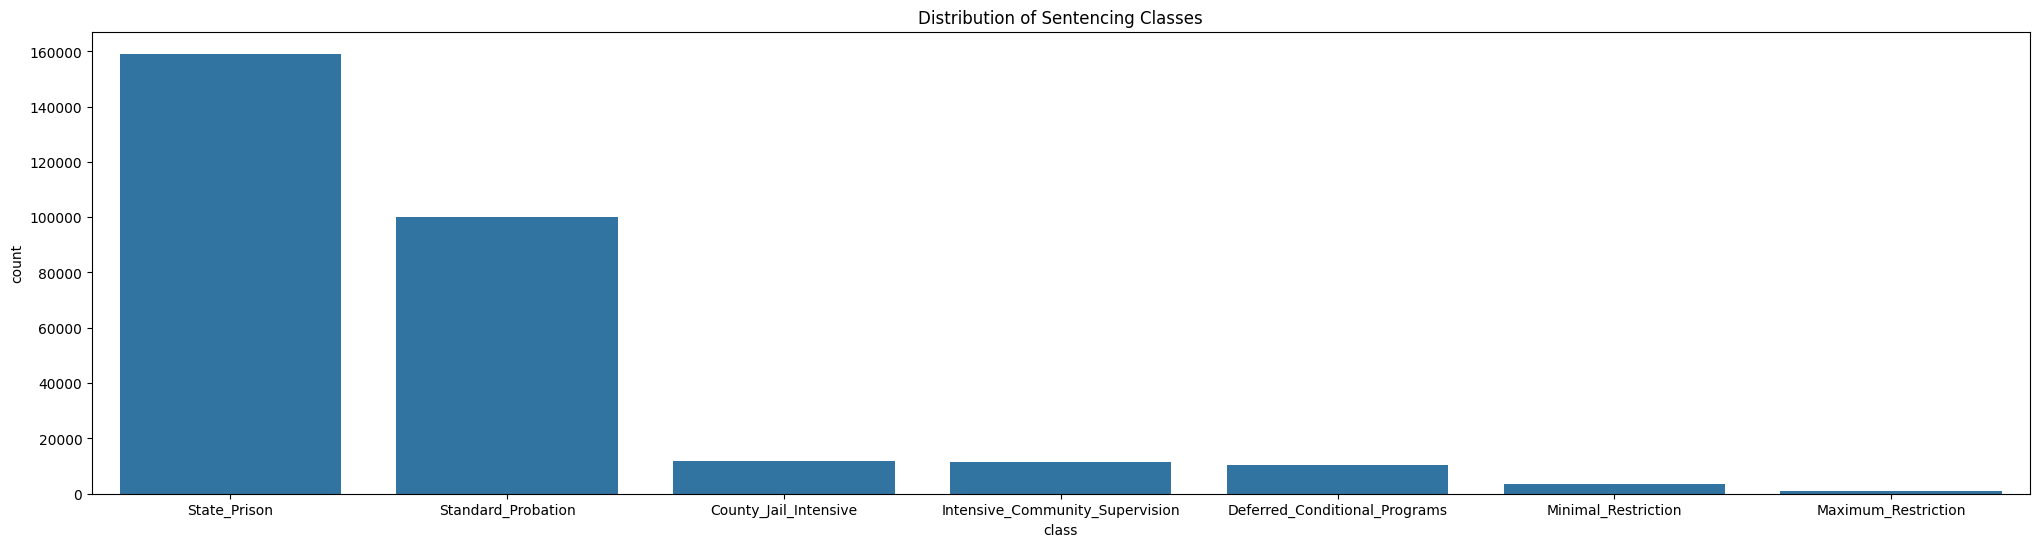

In [62]:

plt.figure(figsize=(25,6))
sns.countplot(data=sent_filtered, x='class', order=sent_filtered['class'].value_counts().index)
plt.title('Distribution of Sentencing Classes')

In [63]:
y_train.value_counts()

class
State_Prison                       143167
Standard_Probation                  90186
County_Jail_Intensive               10529
Intensive_Community_Supervision     10196
Deferred_Conditional_Programs        9356
Minimal_Restriction                  3196
Maximum_Restriction                   715
Name: count, dtype: int64

fixing data imbalance

In [64]:

from collections import Counter
from imblearn.over_sampling import RandomOverSampler
# Combined undersampling (cap large classes) and oversampling (duplicate minorities)
# Do NOT drop any class during this process
print('Training distribution before resampling:')
print(y_train.value_counts())
# Compute per-class counts and choose a cap for majority classes
counts = y_train.value_counts()
cap = int(max(1, counts.median() * 2))  # cap large classes at ~2x median
print(f'Undersample cap per class: {cap}')
# Build index list to keep (no class is removed entirely)
keep_indices = []
for label, cnt in counts.items():
    idx = y_train[y_train == label].index
    if cnt > cap:
        sampled_idx = np.random.RandomState(42).choice(idx, size=cap, replace=False)
        keep_indices.extend(sampled_idx.tolist())
    else:
        keep_indices.extend(idx.tolist())
# Subset without dropping classes
keep_indices = sorted(keep_indices)
X_train = X_train.loc[keep_indices].reset_index(drop=True)
y_train = y_train.loc[keep_indices].reset_index(drop=True)
print('Distribution after undersampling cap:')
print(y_train.value_counts())
# Oversample minority classes to match current majority using RandomOverSampler (safe for singletons)
ros = RandomOverSampler(sampling_strategy='auto', random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)
print('Distribution after oversampling:', Counter(y_train))
print(X_train.shape)
y_train.value_counts()



Training distribution before resampling:
class
State_Prison                       143167
Standard_Probation                  90186
County_Jail_Intensive               10529
Intensive_Community_Supervision     10196
Deferred_Conditional_Programs        9356
Minimal_Restriction                  3196
Maximum_Restriction                   715
Name: count, dtype: int64
Undersample cap per class: 20392
Distribution after undersampling cap:
class
State_Prison                       20392
Standard_Probation                 20392
County_Jail_Intensive              10529
Intensive_Community_Supervision    10196
Deferred_Conditional_Programs       9356
Minimal_Restriction                 3196
Maximum_Restriction                  715
Name: count, dtype: int64
Distribution after oversampling: Counter({'State_Prison': 20392, 'Maximum_Restriction': 20392, 'Deferred_Conditional_Programs': 20392, 'Standard_Probation': 20392, 'County_Jail_Intensive': 20392, 'Minimal_Restriction': 20392, 'Intensive_Commun

class
State_Prison                       20392
Maximum_Restriction                20392
Deferred_Conditional_Programs      20392
Standard_Probation                 20392
County_Jail_Intensive              20392
Minimal_Restriction                20392
Intensive_Community_Supervision    20392
Name: count, dtype: int64

In [65]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [66]:
# from sklearn import datasets

# from sklearn.preprocessing import StandardScaler
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score, classification_report
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

# # 4. Build the SVM model
# svm_clf = SVC(kernel="linear", C=1.0, gamma="scale")   # You can change kernel: "linear", "poly", "rbf", "sigmoid"

# # 5. Train
# svm_clf.fit(X_train, y_train)

# # 6. Predict
# y_pred = svm_clf.predict(X_test)

# # 7. Evaluate
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print(classification_report(y_test, y_pred))

In [67]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
rf_clf = RandomForestClassifier(class_weight='balanced',n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.23725846630310374
                                 precision    recall  f1-score   support

          County_Jail_Intensive       0.05      0.40      0.09      1188
  Deferred_Conditional_Programs       0.08      0.40      0.14      1000
Intensive_Community_Supervision       0.07      0.18      0.10      1077
            Maximum_Restriction       0.04      0.78      0.08        72
            Minimal_Restriction       0.03      0.23      0.05       360
             Standard_Probation       0.45      0.05      0.08     10020
                   State_Prison       0.70      0.34      0.45     15989

                       accuracy                           0.24     29706
                      macro avg       0.21      0.34      0.14     29706
                   weighted avg       0.54      0.24      0.29     29706



In [68]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
# Encode labels to integers for XGBoost compatibility
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Remove deprecated `use_label_encoder` and set a stable eval metric
import re
def sanitize_df(df):
    df = df.copy()
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', str(c)) for c in df.columns]
    return df
X_train_safe = sanitize_df(X_train)
X_test_safe = sanitize_df(X_test)
xgb_clf = XGBClassifier(eval_metric='mlogloss', random_state=42, verbosity=0)
xgb_clf.fit(X_train_safe, y_train_enc)
y_pred_xgb_enc = xgb_clf.predict(X_test_safe)

# Decode predictions back to original labels for reporting (if possible)
try:
    y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)
    y_test_labels = y_test.reset_index(drop=True) if isinstance(y_test, (pd.Series, pd.Index)) else y_test
    print("XGBoost Accuracy:", accuracy_score(y_test_labels, y_pred_xgb))
    print(classification_report(y_test_labels, y_pred_xgb))
except Exception:
    print("XGBoost Accuracy:", accuracy_score(y_test_enc, y_pred_xgb_enc))
    print(classification_report(y_test_enc, y_pred_xgb_enc))


XGBoost Accuracy: 0.24341883794519625
                                 precision    recall  f1-score   support

          County_Jail_Intensive       0.05      0.40      0.09      1188
  Deferred_Conditional_Programs       0.08      0.41      0.14      1000
Intensive_Community_Supervision       0.07      0.16      0.10      1077
            Maximum_Restriction       0.05      0.86      0.09        72
            Minimal_Restriction       0.03      0.26      0.05       360
             Standard_Probation       0.48      0.04      0.07     10020
                   State_Prison       0.71      0.35      0.47     15989

                       accuracy                           0.24     29706
                      macro avg       0.21      0.35      0.15     29706
                   weighted avg       0.55      0.24      0.29     29706

